<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
#install of necessary modules
!pip install opendatasets --upgrade --quiet

In [2]:
#import of modules
import opendatasets as od
import pandas as pd
import numpy as np
from process_bank_churn import preprocess_data, preprocess_new_data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'
od.download(dataset_url)
raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/train.csv')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nadiiababanska
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 35.6MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-4/bank-customer-churn-prediction-dlu-course-c-4.zip to ./bank-customer-churn-prediction-dlu-course-c-4


In [4]:
target_col = 'Exited'
drop_cols = ['id', 'CustomerId', 'Surname']
cat_cols = ['Geography', 'Clients loyality', 'AgeGroup']

In [5]:
data = preprocess_data(target_col, drop_cols, cat_cols, raw_df, scaler_numeric = True)

#Нове посилання на файл з препроцесінгом
https://github.com/fox-n/ML_course_homeworks/blob/main/process_bank_churn.py


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [6]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']


In [7]:
knn = KNeighborsClassifier()

knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [8]:
#ROC curve
def compute_auroc_and_build_roc(inputs, targets, model, build_graph = True, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)


  if build_graph:
    print(f'AUROC for {name}: {roc_auc:.2f}')
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()
  else:
    return roc_auc

AUROC for Training: 0.96


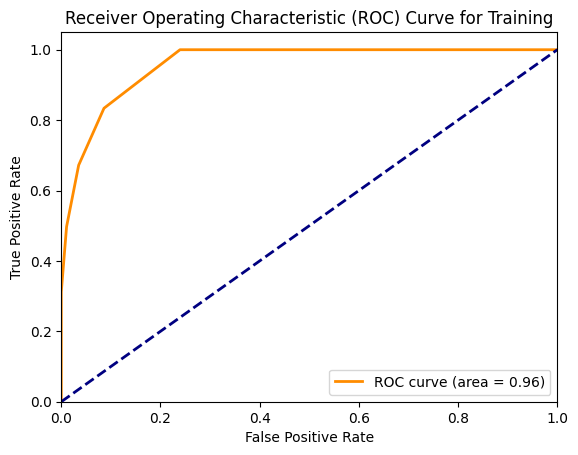

AUROC for Validation: 0.87


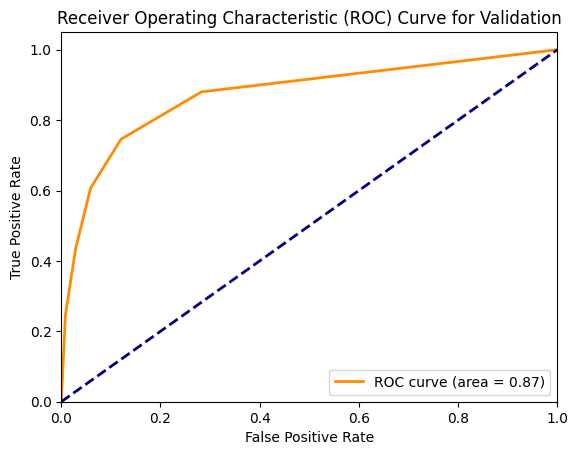

In [9]:
compute_auroc_and_build_roc(X_train, train_targets, knn,True, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, knn,True, 'Validation')


#Висновки
Knn з дефолтними параметрами (k = 5)на тренувальних даних спочатку показав AUROC 0.87, а на валідаційних - 0.66, тобто модель дуже перевчилась на тренувальних даних і показала поганий перфоманс на валідаційних. Але коли я включила маштабування ознак в препроцесингу, картина трохи покращилась: на тренувальних даних AUROC став 0.96, а на валідаційних - 0.87. Модель всеодно перенавчена. А щеб

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [ ]:
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc',
    verbose=5)
knn_gs.fit(X_train, train_targets)

In [11]:
knn_best = knn_gs.best_estimator_
print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(20)} 0.8940205340448969


AUROC for Training: 0.93


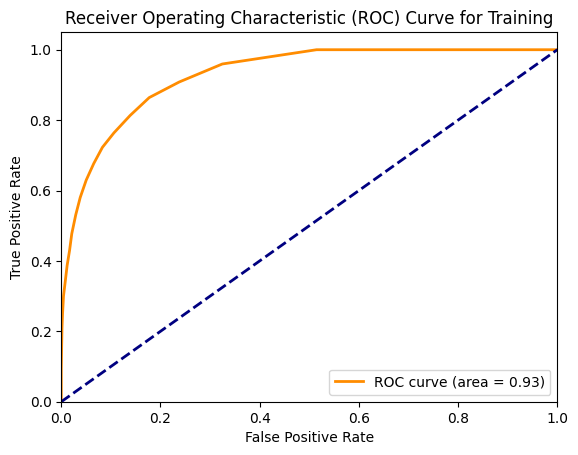

AUROC for Validation: 0.90


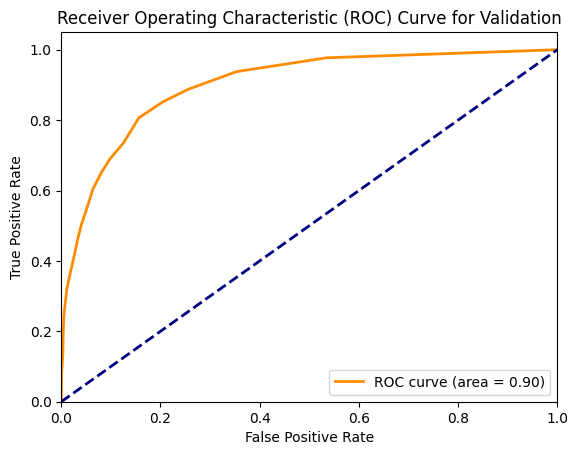

In [12]:
compute_auroc_and_build_roc(X_train, train_targets, knn_best,True, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, knn_best,True, 'Validation')

#Висновок
Після застосування оптимального параметру k, знайденного GridSearchCV (k=20), модель показала вищий AUROC, та значно більшу стабільнисть на валідаційних даних.Проте для дерева з минулого ДЗ, вихидило  добитись меншої різниці в AUROC для тестової та валідаційної вибірки, зміною параметру max_depth

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [13]:
params_tree = {'max_depth': np.arange(1, 21, 2),
               'max_leaf_nodes': np.arange(2, 11, 1)
               }


In [14]:
model = DecisionTreeClassifier(**params_tree, random_state=42)

In [ ]:
%%time
tree_gs = GridSearchCV(model, params_tree, cv=3, scoring='roc_auc',
    verbose=5)
tree_gs.fit(X_train, train_targets)

In [16]:
dt_best = tree_gs.best_estimator_

print(tree_gs.best_params_, tree_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.9013929183420709


AUROC for Training: 0.90


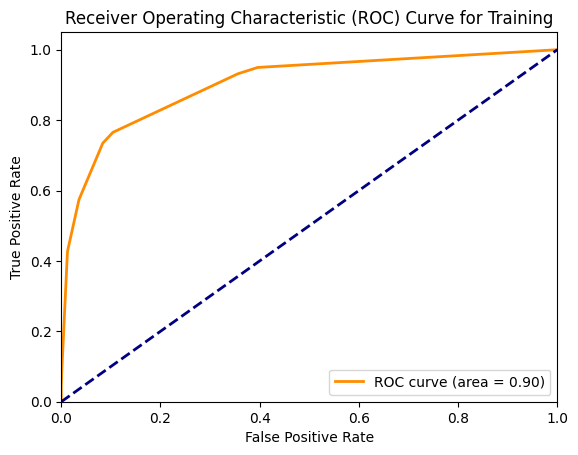

AUROC for Validation: 0.90


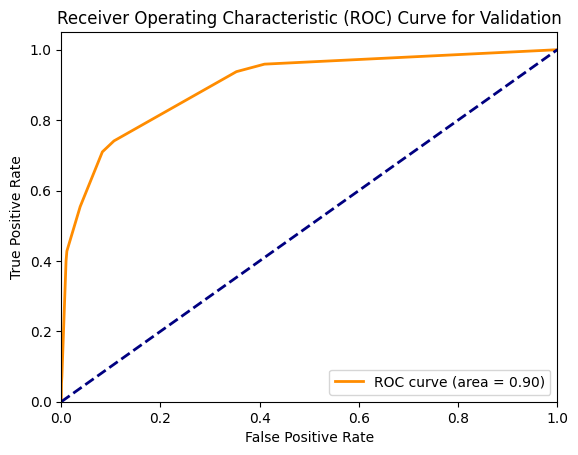

In [17]:
compute_auroc_and_build_roc(X_train, train_targets, dt_best,True, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, dt_best,True, 'Validation')

#Висновок
Вручну я підібрала значення max_depth = 5, max_leaf_nodes = None(або будь-якому значенню (до 20)). З параметрами, підібраними за допомогою GridSearch max_depth = 5, max_leaf_nodes = 10, AUROC трохи знизився (0.91-> 0.90). Пошук параметрів зайняв 7.98 сек
Мені здається, що модель, з параметрами, знайденими вручну - все ж трохи краща. Там трохи вищий AUROC і різниця між AUROC на тренувальних і валідаційних даних менша.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [18]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [20]:
search = RandomizedSearchCV(
    model,
    params_dt,
    n_iter = 40,
    cv=cv,
    scoring='roc_auc',
    verbose=3,
    refit=True
)

In [ ]:
%%time
search.fit(X_train, train_targets)

In [22]:
display(search.best_estimator_, search.best_score_)

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(15),
                       max_leaf_nodes=np.int64(15), min_samples_leaf=8,
                       min_samples_split=5, random_state=42)

np.float64(0.9124226949085706)

In [23]:
dt_random_search_best = search.best_estimator_

AUROC for Training: 0.92


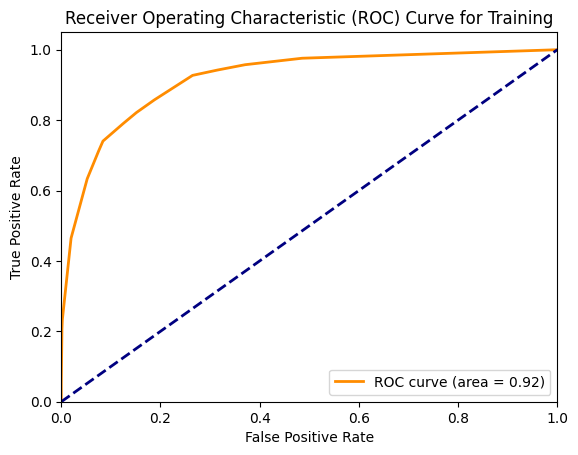

AUROC for Validation: 0.92


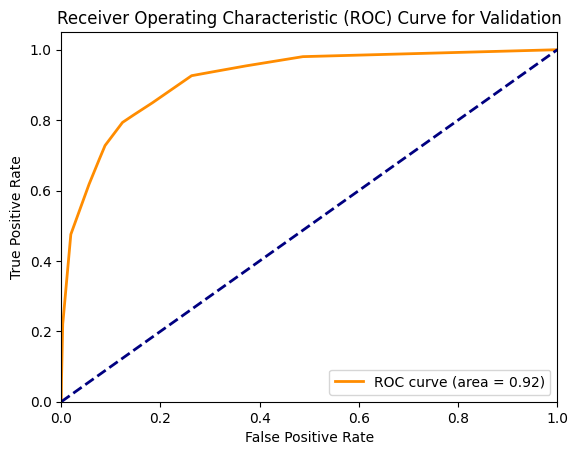

In [24]:
compute_auroc_and_build_roc(X_train, train_targets, dt_random_search_best,True, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, dt_random_search_best,True, 'Validation')

#Висновок
Підбір оптимальних параметрів з Random Search зайняв 2.67 сек, це в 2.5 швидше, ніж з Grid Search. До того ж, якість і стабільність моделі з підібраними Random search параметрами стала значно вищою!

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [25]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [26]:
scaler = data['scaler']
encoder = data['encoder']

In [27]:
test_data = preprocess_new_data(drop_cols, cat_cols, test_raw_df, scaler, encoder)

In [28]:
prob = dt_random_search_best.predict_proba(test_data)[:, 1]

In [29]:
sample_submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')

In [30]:
test_raw_df['Exited'] = prob

sample_submission_df['Exited'] = sample_submission_df['id'].map(
    test_raw_df.set_index('id')['Exited']
)

sample_submission_df.head(5)
sample_submission_df.to_csv('submission_trees.csv', index=False)

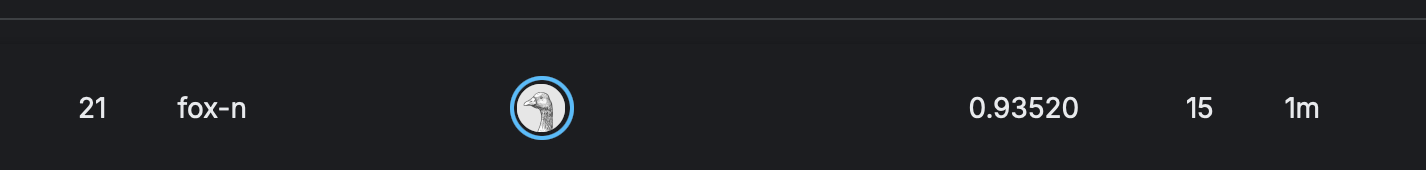